# Diagnostic DINOv3 Baseline
Analyse des prédictions sur le val set.

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
from pathlib import Path
sys.path.insert(0, "/Users/co/Code/DataChallenge2026")

from src.dino.utils import load_config, compute_laplacian_iw

# --- Chargement ---
df = pd.read_csv('../submission/20260613_122649_xgb/val.csv') 

# --- Colonnes dérivées ---
df['pi']       = 1/30 + df['FaceOcclusion']          # poids label
df['iw']        = compute_laplacian_iw(df, alpha=0)
df['w_combined'] = df['iw'] * df['pi']               # produit des deux
df['error']    = (df['pred'] - df['FaceOcclusion'])**2
df['gender_label'] = df['gender'].map({0.0: 'Femme', 1.0: 'Homme'})

print(f"Nb exemples : {len(df)}")
print(df[['FaceOcclusion','pred','iw','pi','w_combined','error']].describe().round(4))

Nb exemples : 20000
       FaceOcclusion        pred          iw          pi  w_combined  \
count     20000.0000  20000.0000  20000.0000  20000.0000  20000.0000   
mean          0.0823      0.0826      1.0000      0.1156      0.1987   
std           0.0861      0.0806      1.0017      0.0861      0.3408   
min           0.0000      0.0000      0.0045      0.0333      0.0029   
25%           0.0180      0.0234      0.3145      0.0513      0.0161   
50%           0.0495      0.0507      0.3145      0.0828      0.0260   
75%           0.1223      0.1183      1.2530      0.1556      0.1950   
max           1.0000      0.4558      9.8189      1.0333      5.0761   

            error  
count  20000.0000  
mean       0.0010  
std        0.0080  
min        0.0000  
25%        0.0000  
50%        0.0002  
75%        0.0007  
max        0.7863  


## 1. Scatterplot prédit vs GT

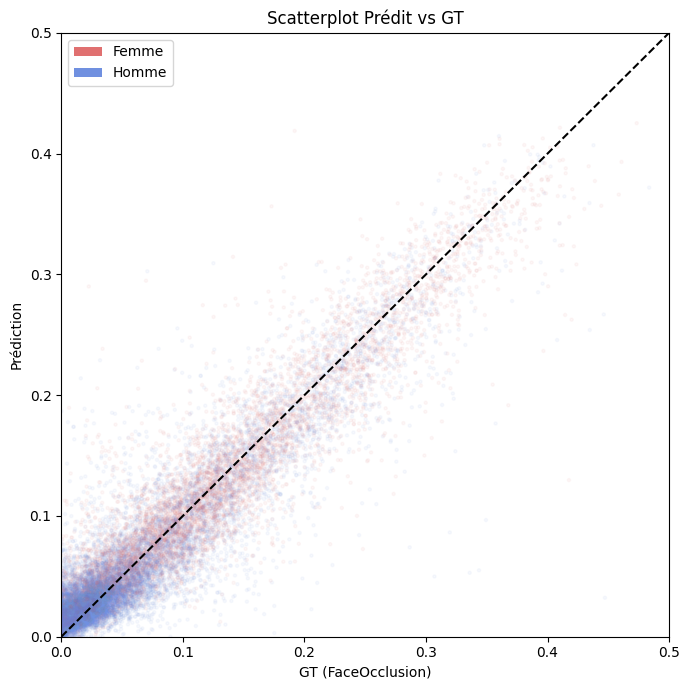

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = df['gender_label'].map({'Femme': '#e07070', 'Homme': '#7090e0'})
ax.scatter(df['FaceOcclusion'], df['pred'], c=colors, alpha=0.05, s=5)

# ligne idéale
ax.plot([0, 0.5], [0, 0.5], 'k--', linewidth=1.5, label='Prédiction parfaite')

# légende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e07070', label='Femme'),
                   Patch(facecolor='#7090e0', label='Homme')]
ax.legend(handles=legend_elements)

ax.set_xlabel('GT (FaceOcclusion)')
ax.set_ylabel('Prédiction')
ax.set_title('Scatterplot Prédit vs GT')
ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

## 2. Distribution des erreurs en fonction de la GT selon 4 pondérations

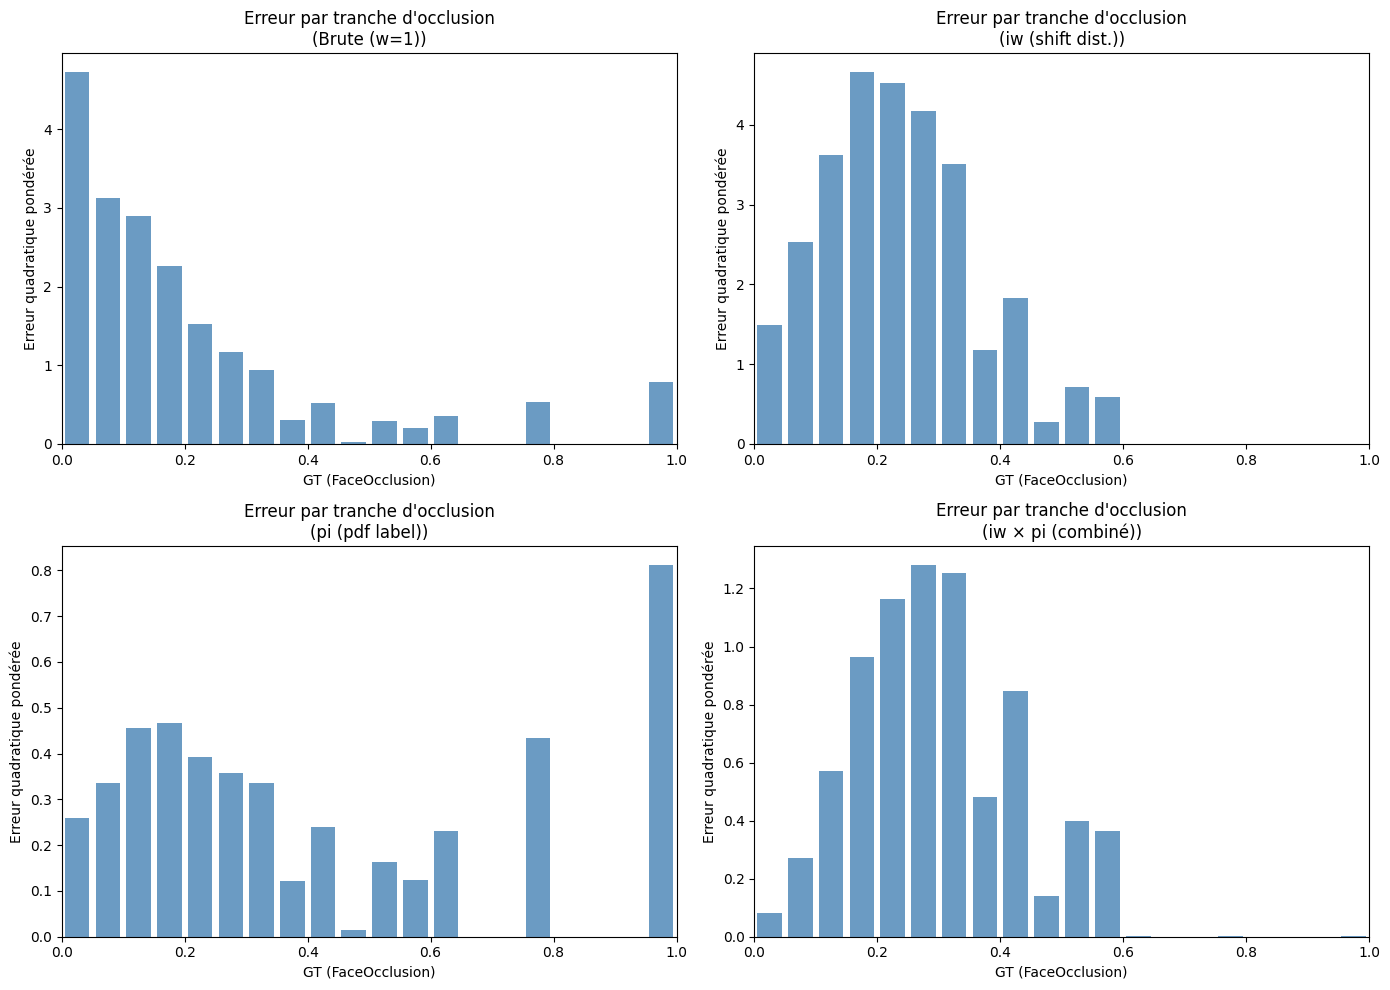

In [4]:
N_BINS = 20
bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
df['bin'] = pd.cut(df['FaceOcclusion'], bins=bins, labels=False, include_lowest=True)

pondérations = {
    'Brute (w=1)':        np.ones(len(df)),
    'iw (shift dist.)':   df['iw'],
    'pi (pdf label)':     df['pi'],
    'iw × pi (combiné)':  df['w_combined'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for ax, (nom, w) in zip(axes, pondérations.items()):
    w = np.array(w)
    erreur_par_bin = []
    for b in range(N_BINS):
        mask = df['bin'] == b
        if mask.sum() == 0:
            erreur_par_bin.append(np.nan)
        else:
            e = df.loc[mask, 'error'].values
            wi = w[mask]
            erreur_par_bin.append(np.sum(wi * e))
    
    ax.bar(bin_centers, erreur_par_bin, width=0.04, color='steelblue', alpha=0.8)
    ax.set_xlabel('GT (FaceOcclusion)')
    ax.set_ylabel('Erreur quadratique pondérée')
    ax.set_title(f'Erreur par tranche d\'occlusion\n({nom})')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 3. Erreur par genre selon les 4 pondérations


=== Score challenge (iw×pi) ===
Err Femme : 0.00144
Err Homme : 0.00264
Score     : 0.00323


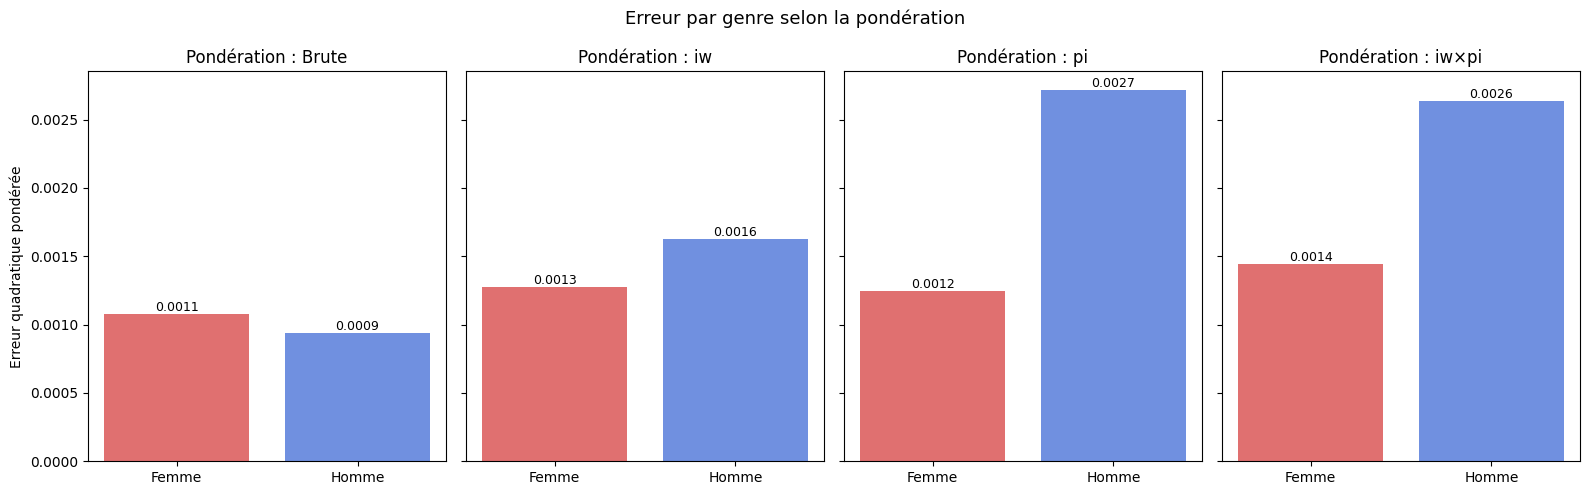

In [5]:
def weighted_mse(df_sub, w):
    w = np.array(w)
    e = df_sub['error'].values
    return np.sum(w * e) / np.sum(w)

results = []
for nom, w_col in [('Brute', np.ones(len(df))),
                   ('iw',    df['iw']),
                   ('pi',    df['pi']),
                   ('iw×pi', df['w_combined'])]:
    w = np.array(w_col)
    for genre in ['Femme', 'Homme']:
        mask = df['gender_label'] == genre
        err = weighted_mse(df[mask], w[mask])
        results.append({'Pondération': nom, 'Genre': genre, 'Erreur': err})

df_results = pd.DataFrame(results)

# Score du challenge pour pondération iw×pi
mask_f = df['gender_label'] == 'Femme'
mask_m = df['gender_label'] == 'Homme'
w = df['w_combined'].values
err_f = weighted_mse(df[mask_f], w[mask_f])
err_m = weighted_mse(df[mask_m], w[mask_m])
score = (err_f + err_m) / 2 + abs(err_f - err_m)
print(f"\n=== Score challenge (iw×pi) ===")
print(f"Err Femme : {err_f:.5f}")
print(f"Err Homme : {err_m:.5f}")
print(f"Score     : {score:.5f}")

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
ponds = df_results['Pondération'].unique()
colors_genre = {'Femme': '#e07070', 'Homme': '#7090e0'}

for ax, pond in zip(axes, ponds):
    sub = df_results[df_results['Pondération'] == pond]
    bars = ax.bar(sub['Genre'], sub['Erreur'],
                  color=[colors_genre[g] for g in sub['Genre']])
    ax.set_title(f'Pondération : {pond}')
    ax.set_ylabel('Erreur quadratique pondérée' if pond == 'Brute' else '')
    for bar, val in zip(bars, sub['Erreur']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Erreur par genre selon la pondération', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Les pires prédictions

=== 20 pires prédictions (erreur absolue) ===
                                                 filename  FaceOcclusion      pred  abs_error gender_label        iw
0     database3/database3/m.02mcr6/92-FaceId-0_align.webp       1.000000  0.113257   0.886743        Homme  0.004538
1    database3/database3/m.01c56w/50-FaceId-54_align.webp       0.782305  0.052978   0.729327        Homme  0.004538
2     database3/database3/m.017m44/19-FaceId-0_align.webp       0.607897  0.007090   0.600807        Homme  0.004538
3     database3/database3/m.01z1pc/41-FaceId-0_align.webp       0.579953  0.130344   0.449610        Homme  2.926133
4    database3/database3/m.014k1v/113-FaceId-0_align.webp       0.447244  0.032246   0.414998        Homme  3.529985
5    database3/database3/m.01mxqdc/52-FaceId-0_align.webp       0.533450  0.154267   0.379183        Homme  2.462318
6     database3/database3/m.027tm9b/1-FaceId-0_align.webp       0.535351  0.232504   0.302847        Homme  2.462318
7     database3/da

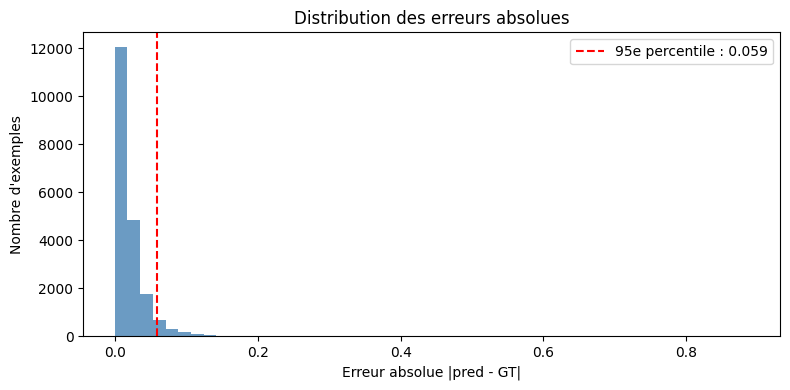

In [6]:
df['abs_error'] = np.abs(df['pred'] - df['FaceOcclusion'])
worst = df.nlargest(20, 'abs_error')[['filename', 'FaceOcclusion', 'pred', 'abs_error', 'gender_label', 'iw']]
worst = worst.reset_index(drop=True)
print("=== 20 pires prédictions (erreur absolue) ===")
print(worst.to_string())

# Distribution des erreurs absolues
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['abs_error'], bins=50, color='steelblue', alpha=0.8)
ax.axvline(df['abs_error'].quantile(0.95), color='red', linestyle='--',
           label=f'95e percentile : {df["abs_error"].quantile(0.95):.3f}')
ax.set_xlabel('Erreur absolue |pred - GT|')
ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Distribution des erreurs absolues')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Analyse du biais de genre et poids de correction

In [7]:
print(df.groupby('gender_label')['FaceOcclusion'].describe())

                count      mean       std  min       25%       50%       75%  \
gender_label                                                                   
Femme          6476.0  0.128211  0.093470  0.0  0.054687  0.109619  0.180884   
Homme         13524.0  0.060255  0.072712  0.0  0.012408  0.031279  0.079183   

                   max  
gender_label            
Femme         0.521161  
Homme         1.000000  


In [8]:
df = pd.read_csv("../data/occlusion_datasets/train.csv").dropna()

gt = df["FaceOcclusion"].values
gender = df["gender"].values  # 0=femme, 1=homme

N_BINS = 30
ALPHA = 50 

bins = np.linspace(0, 1, N_BINS + 1)
bin_idx = np.digitize(gt, bins, right=False) - 1
bin_idx = np.clip(bin_idx, 0, N_BINS - 1)

# Compter les effectifs par bin et genre
n_f = np.zeros(N_BINS)
n_m = np.zeros(N_BINS)
for b in range(N_BINS):
    mask = bin_idx == b
    n_f[b] = np.sum((gender == 0.0) & mask)
    n_m[b] = np.sum((gender == 1.0) & mask)

n_total = n_f + n_m

# Poids par bin avec Bayesian smoothing
w_f = (n_total + 2 * ALPHA) / (2 * (n_f + ALPHA))
w_m = (n_total + 2 * ALPHA) / (2 * (n_m + ALPHA))

# Poids par exemple
weights = np.where(gender == 0.0, w_f[bin_idx], w_m[bin_idx])

# Plot
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bin_centers, n_f, width=0.03, alpha=0.5, label="Femmes", color="crimson")
axes[0].bar(bin_centers, n_m, width=0.03, alpha=0.5, label="Hommes", color="steelblue")
axes[0].set_title("Effectifs par bin")
axes[0].set_xlabel("GT occlusion")
axes[0].legend()

axes[1].plot(bin_centers, w_f, "o-", label="w_F", color="crimson")
axes[1].plot(bin_centers, w_m, "o-", label="w_H", color="steelblue")
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title(f"Poids de rééquilibrage (α={ALPHA})")
axes[1].set_xlabel("GT occlusion")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Poids F : min={w_f.min():.3f}, max={w_f.max():.3f}")
print(f"Poids H : min={w_m.min():.3f}, max={w_m.max():.3f}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/occlusion_datasets/train.csv'